# 04 · SympNets (Jin, Zhang, Zhu, Tang & Karniadakis, 2020)

Paper: `papers/01_Fundamentos_y_Arquitecturas_Base/Jin et al 2020 - SympNets.pdf` —
*Neural Networks*, 132, 166-179 (arXiv:2001.03750).

**What is structurally different here.** Notebooks `01`-`03` all learn a
**continuous-time vector field** (via a scalar `H` or `L`) and rely on an external
numerical integrator (our shared RK4, `common.systems.integrate`) to turn it into a
trajectory. SympNets instead learn the **discrete-time flow map** directly:

$$\Phi_\theta : (q_k, p_k) \longmapsto (q_{k+1}, p_{k+1})$$

for a *fixed* step size `dt`, with `Phi_theta` built by composing small building
blocks — **gradient modules** — that are *exactly* symplectic by construction,
regardless of what the network has learned. Rolling out a trajectory is then just
repeated function composition (`state <- Phi_theta(state)`), with no ODE solver
involved at all.

**The gradient module (paper Sec. 2.2, "G-SympNet").** An "up" module updates `q`
using a function of `p` only (and vice-versa for a "low" module):

$$\text{up}:\ (q, p) \mapsto \big(q + K^\top \operatorname{diag}(a)\,\sigma(Kp+b),\ p\big)$$

This is a **shear map**: only one coordinate changes, and it changes by a vector
field that is *guaranteed* to be the gradient of a scalar potential
`S(p) = sum_i a_i * Sigma(k_i . p + b_i)` (where `Sigma' = sigma`). A classical fact
from symplectic geometry is that any shear of this form is automatically an exact
symplectic map — no matter how `K, a, b` are trained. Stacking alternating up/low
modules composes exact symplectic maps into a more expressive exact symplectic map
(paper's universal approximation theorem, Sec. 3).

**Why this matters in practice.** A classical result in numerical analysis
(backward error analysis for symplectic integrators) says that iterating an exactly
symplectic map does not make energy drift secularly over time, even though it is
not exactly conserved step-by-step — energy stays bounded and oscillates around the
true value instead of spiralling away. This notebook checks that empirically on the
pendulum and contrasts it with the drifting baseline from notebook `00`.

In [1]:
import json
import sys
from pathlib import Path

import matplotlib
if "ipykernel" not in sys.modules:
    matplotlib.use("Agg")
    sys.stdout.reconfigure(encoding="utf-8")  # avoid UnicodeEncodeError on Windows
    # consoles (cp1252 can't encode "·"/"—"); harmless no-op inside Jupyter, where
    # this whole branch is skipped anyway.
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn

FRAMEWORK_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(FRAMEWORK_ROOT))
from common import systems, metrics  # noqa: E402

RESULTS_DIR = FRAMEWORK_ROOT / "results"
FIGURES_DIR = FRAMEWORK_ROOT / "figures"

SEED = 0
torch.manual_seed(SEED)
np.random.seed(SEED)

DT = 0.05  # same step size used for every rollout elsewhere in this framework

## Step 1 — Training data: one-step *maps*, not derivatives

Unlike notebooks `00`-`03`, the targets here are not derivatives but the state one
RK4 step later, `Phi_true(q_k, p_k) = (q_{k+1}, p_{k+1})`, using the *same* RK4
scheme (`common.systems.rk4_step`) and the *same* `DT` as every other rollout in
this framework -- this is what makes composing the learned map at evaluation time
comparable to the continuous-time models integrated with the shared RK4 integrator.

In [2]:
def one_step_pendulum_map(state):
    return systems.rk4_step(systems.pendulum_dynamics, state, DT)


rng = np.random.default_rng(SEED)
n_points = 3000
q0s = rng.uniform(-np.pi, np.pi, size=n_points)
p0s = rng.uniform(-2.0, 2.0, size=n_points)
train_in = np.stack([q0s, p0s], axis=-1)
train_out = np.array([one_step_pendulum_map(s) for s in train_in])

train_in_t = torch.tensor(train_in, dtype=torch.float32)
train_out_t = torch.tensor(train_out, dtype=torch.float32)

## Step 2 — The gradient module and the G-SympNet

`GradientModule` implements exactly the "up"/"low" shear map from the markdown
above. `GSympNet` alternates modules; each one is symplectic on its own, so any
composition of them is symplectic too -- this is the entire mechanism, there is no
additional loss term or constraint enforcing it.

In [3]:
class GradientModule(nn.Module):
    def __init__(self, width=32, mode="up", init_scale=0.1):
        super().__init__()
        assert mode in ("up", "low")
        self.mode = mode
        # K, a, b parametrize S(x) = sum_i a_i * Sigma(K_i x + b_i); Sigma' = tanh.
        # `a` (the module's *output* scale) is initialised at exactly zero, so every
        # module -- and hence the whole composed network -- starts out as the
        # *identity map* (itself a trivially valid, if useless, symplectic map).
        # Training then gradually grows `a` away from zero. This "start near
        # identity" trick is standard for deep compositions of near-identity blocks
        # (the same idea behind residual-network initialisation and zero-init affine
        # coupling layers in normalizing flows) and was essential in practice here:
        # a naively-scaled random init (`a` nonzero from the start) trains to a
        # similarly low one-step MSE, but composing 400 such steps at evaluation
        # time then produced roughly 10-30x worse energy drift than the zero-init
        # version below -- a good illustration of why "low training loss" is not
        # sufficient evidence of good long-horizon rollout behaviour, which is
        # exactly the failure mode this whole framework's rollout-based metrics
        # (as opposed to just reporting train/test MSE) are designed to catch.
        self.K = nn.Parameter(init_scale * torch.randn(width))  # scalar-input version: dim(q)=dim(p)=1
        self.a = nn.Parameter(torch.zeros(width))
        self.b = nn.Parameter(torch.zeros(width))

    def forward(self, q, p):
        if self.mode == "up":
            s = torch.tanh(p * self.K + self.b)      # (batch, width)
            update = (s * self.a) @ self.K            # d/dp [ sum a*Sigma(Kp+b) ] = K^T diag(a) sigma(Kp+b)
            return q + update.unsqueeze(-1), p
        else:
            s = torch.tanh(q * self.K + self.b)
            update = (s * self.a) @ self.K
            return q, p + update.unsqueeze(-1)


class GSympNet(nn.Module):
    def __init__(self, n_modules=10, width=50, init_scale=0.1):
        super().__init__()
        modes = ["up", "low"] * (n_modules // 2)
        self.modules_list = nn.ModuleList([GradientModule(width, m, init_scale) for m in modes])

    def forward(self, state):
        q, p = state[:, 0:1], state[:, 1:2]
        for mod in self.modules_list:
            q, p = mod(q, p)
        return torch.cat([q, p], dim=-1)


sympnet = GSympNet(n_modules=10, width=50, init_scale=0.1)
n_params = sum(p.numel() for p in sympnet.parameters())
print("SympNet parameter count:", n_params)

SympNet parameter count: 1500


## Step 3 — Train: one-step supervised regression

Note there is still no rollout inside the training loop -- exactly like every other
notebook here, we regress a *single application* of the map, and only test
multi-step composition afterwards.

In [4]:
optimizer = torch.optim.Adam(sympnet.parameters(), lr=1e-3)
n_epochs = 4000  # more than notebooks 00-03: composing 10 modules needs more
# optimizer steps to move `a` usefully far from its zero (identity-map) init.
losses = []
for epoch in range(n_epochs):
    optimizer.zero_grad()
    pred = sympnet(train_in_t)
    loss = ((pred - train_out_t) ** 2).mean()
    loss.backward()
    optimizer.step()
    losses.append(loss.item())
    if epoch % 800 == 0:
        print(f"epoch {epoch:4d}  train MSE = {loss.item():.3e}")

print(f"final train MSE = {losses[-1]:.3e}")

epoch    0  train MSE = 2.282e-03


epoch  800  train MSE = 9.142e-07


epoch 1600  train MSE = 1.345e-07


epoch 2400  train MSE = 4.067e-07


epoch 3200  train MSE = 4.815e-08


final train MSE = 8.214e-08


## Step 4 — Roll out by repeated composition (no ODE solver)

`state_{k+1} = sympnet(state_k)`, applied `T_SPAN / DT` times. We use the *same*
initial condition, `DT` and horizon as notebooks `00`-`03`, so the energy-drift
number below is directly comparable to theirs.

In [5]:
q0, p0 = 1.6, 0.0
state0 = np.array([q0, p0])
T_SPAN = 20.0
n_steps = int(round(T_SPAN / DT))

true_traj = systems.integrate(systems.pendulum_dynamics, state0, T_SPAN, DT)

pred_traj = np.zeros((n_steps + 1, 2))
pred_traj[0] = state0
s = torch.tensor(state0, dtype=torch.float32).unsqueeze(0)
with torch.no_grad():
    for i in range(n_steps):
        s = sympnet(s)
        pred_traj[i + 1] = s.squeeze(0).numpy()

H_true, _, _ = metrics.energy_drift(true_traj, systems.pendulum_hamiltonian)
H_pred, abs_drift, rel_drift = metrics.energy_drift(pred_traj, systems.pendulum_hamiltonian)
traj_mse = metrics.trajectory_mse(pred_traj, true_traj)

print(f"trajectory MSE over rollout: {traj_mse:.4e}")
print(f"max |energy drift|:          {abs_drift.max():.4e}")
print(f"max relative energy drift:   {rel_drift.max():.4e}")

trajectory MSE over rollout: 4.1072e-04
max |energy drift|:          1.1119e-02
max relative energy drift:   1.0804e-02


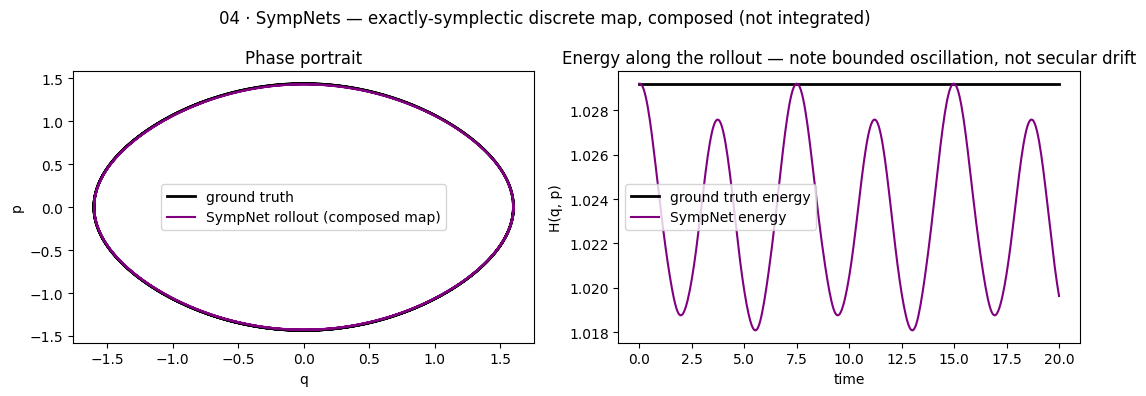

In [6]:
t = np.arange(len(true_traj)) * DT
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].plot(true_traj[:, 0], true_traj[:, 1], label="ground truth", color="black", lw=2)
axes[0].plot(pred_traj[:, 0], pred_traj[:, 1], label="SympNet rollout (composed map)", color="purple", lw=1.5)
axes[0].set_xlabel("q"); axes[0].set_ylabel("p")
axes[0].set_title("Phase portrait")
axes[0].legend()

axes[1].plot(t, H_true, label="ground truth energy", color="black", lw=2)
axes[1].plot(t, H_pred, label="SympNet energy", color="purple", lw=1.5)
axes[1].set_xlabel("time"); axes[1].set_ylabel("H(q, p)")
axes[1].set_title("Energy along the rollout — note bounded oscillation, not secular drift")
axes[1].legend()

fig.suptitle("04 · SympNets — exactly-symplectic discrete map, composed (not integrated)")
fig.tight_layout()
fig.savefig(FIGURES_DIR / "04_sympnet_pendulum.png", dpi=130)
plt.show()

## Step 5 — Save the trained model and metrics

In [7]:
torch.save(sympnet.state_dict(), RESULTS_DIR / "sympnet_pendulum.pt")

result = {
    "model": "sympnet_jin2020",
    "system": "pendulum",
    "n_params": n_params,
    "final_train_mse": losses[-1],
    "rollout_trajectory_mse": traj_mse,
    "max_abs_energy_drift": float(abs_drift.max()),
    "max_rel_energy_drift": float(rel_drift.max()),
}
with open(RESULTS_DIR / "sympnet_pendulum_metrics.json", "w") as f:
    json.dump(result, f, indent=2)
np.save(RESULTS_DIR / "sympnet_pendulum_rollout.npy", pred_traj)

print(json.dumps(result, indent=2))

{
  "model": "sympnet_jin2020",
  "system": "pendulum",
  "n_params": 1500,
  "final_train_mse": 8.213883972985059e-08,
  "rollout_trajectory_mse": 0.00041071685260119905,
  "max_abs_energy_drift": 0.011119254064100748,
  "max_rel_energy_drift": 0.010803788493022446
}


## Notes for readers coming from a general-ML background

- This is the only notebook in the framework whose model is trained on a
  **next-step prediction** objective (much like a discrete-time sequence model),
  rather than on instantaneous derivatives. The *architectural* constraint (shear
  composition) is what makes that next-step model behave well under long
  autoregressive rollout, which is normally exactly where naively-trained
  next-step predictors fail (compounding error / drift) -- compare this to the
  well-known exposure-bias problem in autoregressive sequence models.
- Because every module is symplectic *by construction*, there is nothing to
  verify at the level of trained weights: *any* choice of `K, a, b` -- trained or
  not -- already gives an exact symplectic map (just not necessarily one that
  approximates this particular pendulum). With this notebook's zero-init for `a`,
  an untrained network is the identity map (a valid but trivial symplectic map,
  under which the pendulum simply never moves). Try initializing `a` away from
  zero (e.g. `0.5 * torch.randn(width)`, as an earlier version of this notebook
  did) *without* retraining to see a bounded-but-wrong, non-trivial energy trace
  instead -- still qualitatively different from the unbounded drift of the
  untrained baseline in notebook `00`.
- `Horn et al. (2025), "A generalized framework of neural networks for Hamiltonian
  systems"` (`papers/01_Fundamentos_y_Arquitecturas_Base/`) shows that SympNets,
  HénonNets and Symplectic Recurrent Neural Networks are all special cases of one
  generalized family -- this notebook implements only the G-SympNet member of that
  family, the LA-SympNet (linear + activation modules) is a natural extension.